# JOB-ANALYZER

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

In [3]:
url = "https://jsearch.p.rapidapi.com/search"

querystring = {
    "query": "data analyst india",
    "page": "1",
    "num_pages": "1"
}

headers = {
    "X-RapidAPI-Key": "adf06cba27mshb184790183c6e70p1d2282jsnc4f6605c02c9",
    "X-RapidAPI-Host": "jsearch.p.rapidapi.com"
}

response = requests.get(url, headers=headers, params=querystring)
data = response.json()

In [27]:
skill_input = input("Enter skills (comma-separated): ")

skills_list = [skill.strip().lower() for skill in skill_input.split(",")]

print("Skills to search:", skills_list)

Skills to search: ['python', 'sql', 'os', 'excel', 'power bi']


In [28]:
def extract_skills(text, skills):
    found = []
    text = str(text).lower()
    
    for skill in skills:
        if skill in text:
            found.append(skill)
    
    return found

In [29]:
jobs = []

for job in data.get("data", []):
    description = job.get("job_description")
    
    jobs.append({
        "Title": job.get("job_title"),
        "Company": job.get("employer_name"),
        "Location": job.get("job_city"),
        "Skills": extract_skills(description, skills_list)
    })

df = pd.DataFrame(jobs)

df

,Title,Company,Location,Skills
0,Senior Data Analyst,Mastercard,Navi Mumbai,"[python, sql, os]"
1,Sr Analyst – Treasury Data Analytics,United Airlines,Gurugram,"[python, sql, os, excel, power bi]"
2,Senior Analyst - Business Intelligence (Data A...,Gallagher,Pune,"[python, os, excel, power bi]"
3,Senior Data Analyst,Chevron,Bengaluru,"[python, sql, os, excel, power bi]"
4,"Senior Data Analyst | Mumbai, IN | Remote",Ambition,None,"[os, excel, power bi]"
5,Data Analyst (Sales Operations) - India,TableCheck,Mumbai,"[python, sql, os, excel, power bi]"
6,Senior Associate Data Science Analyst,Equinix,Bengaluru,"[python, sql, os]"
7,Sr. Data Analyst,CBTS,Chennai,"[sql, os]"
8,Data Analyst - Cross Sell & Retention Analytics,Godrej Group,Mumbai,"[python, sql, os, excel]"
9,Master Data Analyst - SCM,Hitachi Careers,Bengaluru,"[sql, os, excel, power bi]"


In [30]:
all_skills = []

for skills in df['Skills']:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Count'])

skill_df = skill_df.sort_values(by='Count', ascending=False)

skill_df

,Skill,Count
2,os,10
1,sql,8
0,python,7
3,excel,7
4,power bi,6


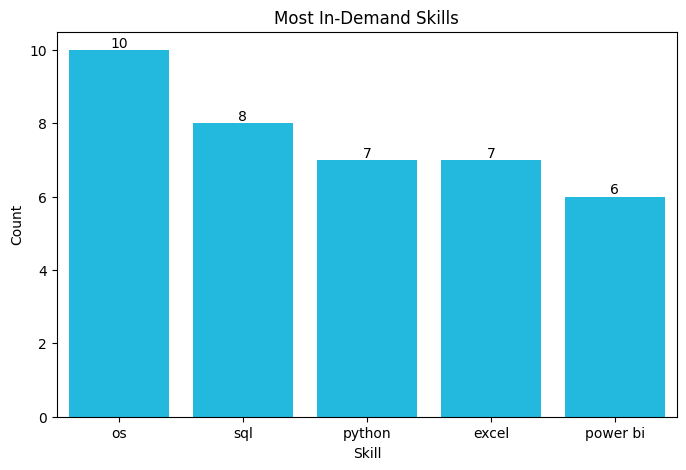

In [31]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x='Skill', y='Count', data=skill_df,color="#04CCFE")
for bars in ax.containers:
            ax.bar_label(bars)
plt.title("Most In-Demand Skills")
plt.show()

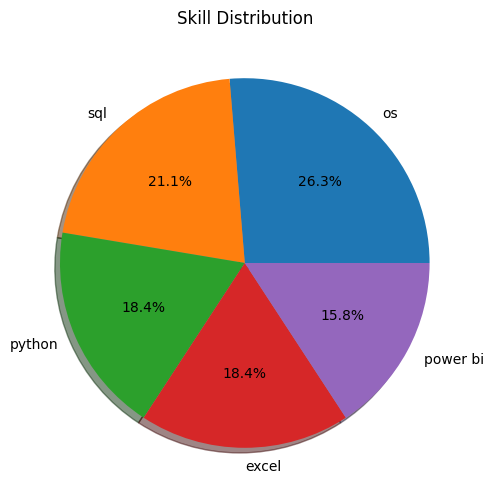

In [32]:
plt.figure(figsize=(6,6))
plt.pie(skill_df['Count'], labels=skill_df['Skill'], autopct='%1.1f%%',shadow=True)
plt.title("Skill Distribution")
plt.show()

In [33]:
top_skill = skill_df.iloc[0]

print(" Most Demanded Skill:", top_skill['Skill'])
print(" Count:", top_skill['Count'])

 Most Demanded Skill: os
 Count: 10
